# OTel Metrics ETL - Interactive Example

This notebook demonstrates the OTel Metrics ETL pipeline for transforming high-cardinality OpenTelemetry metrics into ML-ready features.

In [1]:
import sys
sys.path.insert(0, '..')

from datetime import datetime, timedelta
import pandas as pd
import numpy as np

from otel_etl import run_profiler, fetch_and_denormalize
from otel_etl.utils import PrometheusClient
from otel_etl.feature_generator.schema_registry import SchemaRegistry

# Configuration
PROMETHEUS_URL = "http://10.0.0.5:9090"

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

## Step 1: Profile Metrics

Run the profiler to discover metrics, labels, and cardinality.

In [2]:
schema = run_profiler(
    prometheus_url=PROMETHEUS_URL,
    output_path="schema_config.yaml",
    profiling_window_hours=1,
    cardinality_thresholds={
        "tier1_max": 10,
        "tier2_max": 50,
        "tier3_max": 200,
    },
)

print(f"Discovered {len(schema['metrics'])} metric families")
print(f"Profiled at: {schema['profiled_at']}")

Discovered 406 metric families
Profiled at: 2026-01-18T16:19:35.379224Z


### Inspect Schema Config

In [3]:
# Show a sample metric family
sample_family = list(schema['metrics'].keys())[0]
print(f"\nSample metric family: {sample_family}")
print(f"Type: {schema['metrics'][sample_family]['type']}")
print(f"\nLabels:")
for label, info in schema['metrics'][sample_family]['labels'].items():
    print(f"  {label}: tier={info['tier']}, cardinality={info['cardinality']}, action={info['action']}")


Sample metric family: app_ads_ad_requests
Type: counter

Labels:
  app_ads_ad_response_type: tier=1, cardinality=2, action=keep
  instance: tier=1, cardinality=1, action=keep
  app_ads_ad_request_type: tier=1, cardinality=2, action=keep
  host_name: tier=1, cardinality=1, action=keep
  service_namespace: tier=1, cardinality=1, action=keep
  service_instance_id: tier=1, cardinality=1, action=drop
  service_name: tier=1, cardinality=1, action=keep
  job: tier=1, cardinality=1, action=keep
  service_version: tier=1, cardinality=1, action=keep


## Step 2: Fetch and Transform Metrics

In [4]:
end_time = datetime.utcnow()
start_time = end_time - timedelta(minutes=30)

features_df = fetch_and_denormalize(
    prometheus_url=PROMETHEUS_URL,
    start=start_time,
    end=end_time,
    step="60s",
    schema_config="schema_config.yaml",
    column_registry="column_registry.yaml",
    layers=[1, 2, 3],
    include_deltas=True,
)

print(f"Shape: {features_df.shape}")
print(f"Entities: {features_df['entity_key'].nunique()}")
print(f"Features: {len([c for c in features_df.columns if c not in ['timestamp', 'entity_key']])}")

/var/folders/m_/vc9m61jj6vz7rfg12ptx38l40000gn/T/ipykernel_28280/879078675.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time = datetime.utcnow()
/Users/neil/sideProjects/opentelemetry-demo/_notebook/examples/../otel_etl/feature_generator/delta_features.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[delta_col_name] = result[col] - shifted
/Users/neil/sideProjects/opentelemetry-demo/_notebook/examples/../otel_etl/feature_generator/delta_features.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

Shape: (243, 6776)
Entities: 17
Features: 6774


/Users/neil/sideProjects/opentelemetry-demo/_notebook/examples/../otel_etl/feature_generator/delta_features.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[pct_col_name] = pct_change
/Users/neil/sideProjects/opentelemetry-demo/_notebook/examples/../otel_etl/feature_generator/delta_features.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[pct_col_name] = pct_change
/Users/neil/sideProjects/opentelemetry-demo/_notebook/examples/../otel_etl/feature_generator/delta_features.py:99: PerformanceWarning: DataFrame

### Inspect Output

In [5]:
# Show first few rows
features_df.head()

,timestamp,entity_key,aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop,aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m,aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m__pct_change_60m,...,v8js_memory_heap_used_bytes__stddev__host_name_docker_desktop__job_opentelemetry_demo_payment__service_name_payment__delta_5m,v8js_memory_heap_used_bytes__stddev__host_name_docker_desktop__job_opentelemetry_demo_payment__service_name_payment__delta_5m__pct_change_60m,v8js_memory_heap_used_bytes__stddev__host_name_docker_desktop__job_opentelemetry_demo_payment__service_name_payment__delta_60m,v8js_memory_heap_used_bytes__stddev__host_name_docker_desktop__job_opentelemetry_demo_payment__service_name_payment__delta_60m__pct_change_60m,v8js_memory_heap_used_bytes__stddev__host_name_docker_desktop__job_opentelemetry_demo_payment__service_name_payment__pct_change_60m
0,2026-01-18 11:05:35.645,default,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN
11,2026-01-18 11:06:35.645,default,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN
25,2026-01-18 11:07:35.645,default,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN
41,2026-01-18 11:08:35.645,default,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN
57,2026-01-18 11:09:35.645,default,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN


In [6]:
# Show feature columns
feature_cols = [c for c in features_df.columns if c not in ['timestamp', 'entity_key']]
print(f"Total features: {len(feature_cols)}")
print(f"\nSample features:")
for col in feature_cols[:10]:
    print(f"  - {col}")

Total features: 6774

Sample features:
  - aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop
  - aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m
  - aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m__pct_change_60m
  - aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_60m
  - aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_60m__pct_change_60m
  - aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__pct_change_60m
  - aspnetcore_memory_pool_pooled_bytes__max__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop
  - aspnetcore_memory_pool_pooled_bytes__max__aspnetcore_memory_pool_owner_kestrel__host_name_docker_d

## Step 3: Analyze Features

In [7]:
# Completeness analysis
completeness_by_column = features_df[feature_cols].notna().mean()
print(f"Median completeness: {completeness_by_column.median():.1%}")
print(f"Sparse columns (>50% NaN): {(completeness_by_column < 0.5).sum()}")

# Show sparsest columns
print("\nSparsest features:")
print(completeness_by_column.nsmallest(5))

Median completeness: 0.0%
Sparse columns (>50% NaN): 6774

Sparsest features:
aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m__pct_change_60m     0.0
aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_60m                    0.0
aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_60m__pct_change_60m    0.0
aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__pct_change_60m               0.0
aspnetcore_memory_pool_pooled_bytes__max__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m__pct_change_60m      0.0
dtype: float64


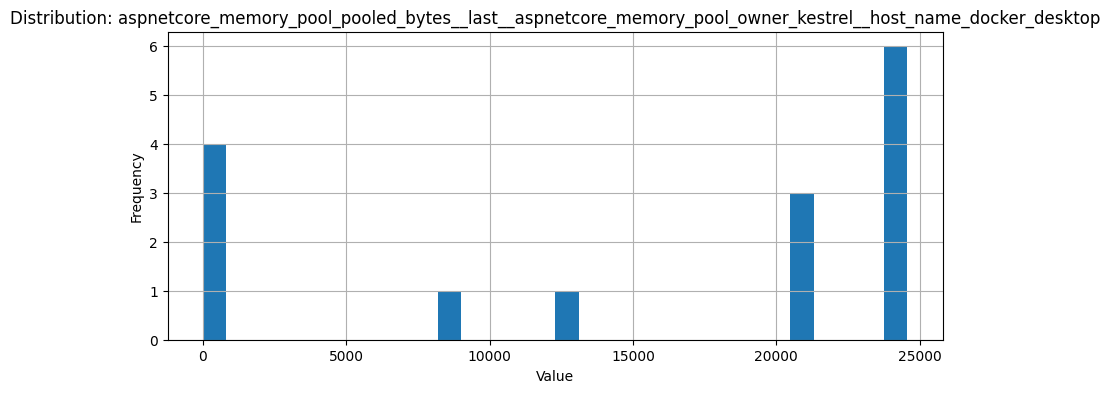

In [8]:
# Feature value distribution
import matplotlib.pyplot as plt

# Plot histogram of a sample feature
sample_feature = feature_cols[0]
features_df[sample_feature].hist(bins=30, figsize=(10, 4))
plt.title(f"Distribution: {sample_feature}")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## Step 4: Feature Engineering Examples

Entity: default
Rows: 15


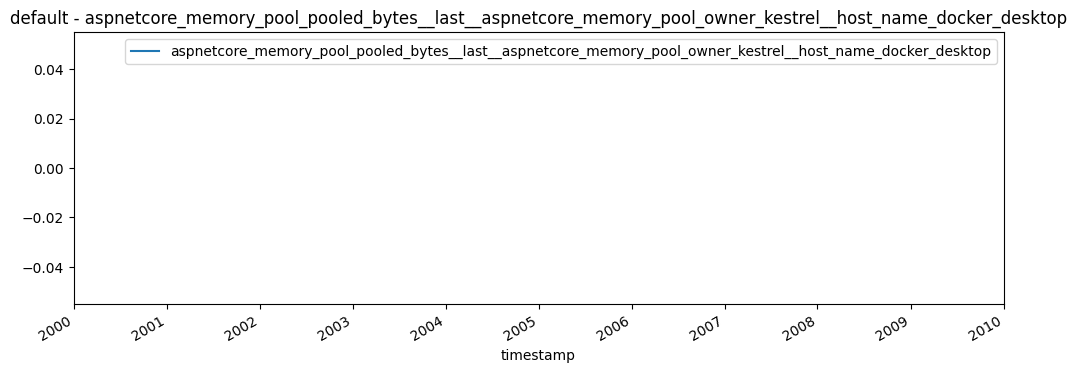

In [9]:
# Filter to a specific entity
entities = features_df['entity_key'].unique()
if len(entities) > 0:
    entity = entities[0]
    entity_df = features_df[features_df['entity_key'] == entity].copy()
    
    print(f"Entity: {entity}")
    print(f"Rows: {len(entity_df)}")
    
    # Plot time series of a feature
    if len(feature_cols) > 0:
        feature = feature_cols[0]
        entity_df.plot(x='timestamp', y=feature, figsize=(12, 4), title=f"{entity} - {feature}")
        plt.show()

In [10]:
# Find highly correlated features
corr_matrix = features_df[feature_cols].corr()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (>0.9):")
    for feat1, feat2, corr in high_corr_pairs[:5]:
        print(f"  {corr:.3f}: {feat1} <-> {feat2}")
else:
    print("No highly correlated features found")

Found 12176 highly correlated feature pairs (>0.9):
  1.000: aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop <-> aspnetcore_memory_pool_pooled_bytes__max__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop
  1.000: aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop <-> aspnetcore_memory_pool_pooled_bytes__mean__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop
  1.000: aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop <-> aspnetcore_memory_pool_pooled_bytes__min__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop
  1.000: aspnetcore_memory_pool_pooled_bytes__last__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m <-> aspnetcore_memory_pool_pooled_bytes__max__aspnetcore_memory_pool_owner_kestrel__host_name_docker_desktop__delta_5m
  1.000: aspnetcore_memory_pool

## Step 5: Export for ML

In [11]:
# Prepare for ML: drop index columns, fill NaNs
X = features_df[feature_cols].fillna(0)

print(f"Feature matrix shape: {X.shape}")
print(f"Data type: {X.dtypes[0]}")
print(f"Memory usage: {X.memory_usage().sum() / 1024**2:.1f} MB")

# Save
X.to_csv("otel_tel_features.csv", index=False)
print("\n✓ Saved otel_tel_features.csv")

Feature matrix shape: (243, 6774)
Data type: float64
Memory usage: 12.6 MB


/var/folders/m_/vc9m61jj6vz7rfg12ptx38l40000gn/T/ipykernel_28280/3790309990.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Data type: {X.dtypes[0]}")



✓ Saved features_for_ml.csv
